In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize and flatten
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Encoder
encoder = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu")
])

# Decoder
decoder = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")
])

# Autoencoder
autoencoder = keras.Sequential([
    encoder,
    decoder
])

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.2263 - val_loss: 0.1442
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1274 - val_loss: 0.1138
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1091 - val_loss: 0.1021
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0999 - val_loss: 0.0957
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0949 - val_loss: 0.0920
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0917 - val_loss: 0.0891
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0893 - val_loss: 0.0869
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0872 - val_loss: 0.0853
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0856 - val_loss: 0.0840
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0844 - val_loss: 0.0831


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


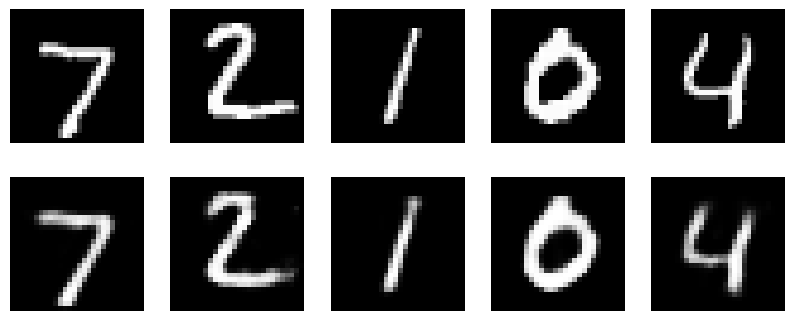

In [2]:
reconstructed = autoencoder.predict(x_test[:10])

plt.figure(figsize=(10, 4))

for i in range(5):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

In [3]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

sparse_autoencoder = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(
        128,
        activation="relu",
        activity_regularizer=regularizers.l1(1e-5)
    ),

    layers.Dense(64, activation="relu"),

    layers.Dense(128, activation="relu"),

    layers.Dense(784, activation="sigmoid")
])

sparse_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

sparse_autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.2922 - val_loss: 0.2040
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1880 - val_loss: 0.1744
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1677 - val_loss: 0.1599
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1551 - val_loss: 0.1486
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1471 - val_loss: 0.1432
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1420 - val_loss: 0.1385
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1374 - val_loss: 0.1340
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1336 - val_loss: 0.1313
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1306 - val_loss: 0.1279
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1280 - val_loss: 0.1256


In [4]:
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [5]:
denoising_autoencoder = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")
])

denoising_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

denoising_autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.2394 - val_loss: 0.1630
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1501 - val_loss: 0.1376
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1316 - val_loss: 0.1243
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1219 - val_loss: 0.1171
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1159 - val_loss: 0.1124
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1116 - val_loss: 0.1088
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1086 - val_loss: 0.1062
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1064 - val_loss: 0.1046
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1044 - val_loss: 0.1030
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1028 - val_loss: 0.1011


In [6]:
denoising_autoencoder = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")
])

denoising_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

denoising_autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.2369 - val_loss: 0.1612
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1468 - val_loss: 0.1330
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1281 - val_loss: 0.1217
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1190 - val_loss: 0.1144
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1130 - val_loss: 0.1100
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1089 - val_loss: 0.1061
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1060 - val_loss: 0.1041
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1040 - val_loss: 0.1027
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1022 - val_loss: 0.1006
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1009 - val_loss: 0.0996


In [8]:
x_train_img = x_train.reshape(-1, 28, 28, 1)
x_test_img = x_test.reshape(-1, 28, 28, 1)

In [9]:
conv_autoencoder = keras.Sequential([

    # Encoder
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2, 2), padding="same"),

    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2, 2), padding="same"),

    # Decoder
    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same"
    )
])

conv_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

conv_autoencoder.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
conv_autoencoder.fit(
    x_train_img,
    x_train_img,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_img, x_test_img)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 198ms/step - loss: 0.1225 - val_loss: 0.0790
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 201ms/step - loss: 0.0769 - val_loss: 0.0742
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 200ms/step - loss: 0.0736 - val_loss: 0.0720
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 199ms/step - loss: 0.0720 - val_loss: 0.0708
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 201ms/step - loss: 0.0710 - val_loss: 0.0699
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 198ms/step - loss: 0.0702 - val_loss: 0.0698
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 199ms/step - loss: 0.0696 - val_loss: 0.0688
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 204ms/step - loss: 0.0691 - val_loss: 0.0683
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 200ms/step - loss: 0.0687 - val_loss: 0.0680
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - loss: 0.0684 - val_loss: 0.0677


In [11]:
class ContractiveAutoencoder(keras.Model):

    def __init__(self, latent_dim=64):
        super().__init__()

        self.encoder_layer = layers.Dense(
            latent_dim,
            activation="relu"
        )

        self.decoder = layers.Dense(
            784,
            activation="sigmoid"
        )

    def call(self, x):
        z = self.encoder_layer(x)
        output = self.decoder(z)
        return output

In [12]:
latent_dim = 2

# Encoder
encoder_inputs = keras.Input(shape=(784,))

x = layers.Dense(256, activation="relu")(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [13]:
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(
            shape=(batch, dim)
        )

        return z_mean + tf.exp(
            0.5 * z_log_var
        ) * epsilon

In [14]:
z = Sampling()([z_mean, z_log_var])

In [15]:
latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(256, activation="relu")(x)

decoder_outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

In [16]:
timesteps = 50
features = 1
latent_dim = 16

inputs = keras.Input(
    shape=(timesteps, features)
)

# Encoder
encoded = layers.LSTM(
    latent_dim
)(inputs)

# Repeat latent vector
x = layers.RepeatVector(timesteps)(encoded)

# Decoder
x = layers.LSTM(
    32,
    return_sequences=True
)(x)

outputs = layers.TimeDistributed(
    layers.Dense(features)
)(x)

rnn_autoencoder = keras.Model(
    inputs,
    outputs
)

rnn_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

rnn_autoencoder.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,457 (29.13 KB)

 Trainable params: 7,457 (29.13 KB)

 Non-trainable params: 0 (0.00 B)